# Twitter Sentiment Analysis

This notebook starts with the foundations needed for the assessment:

- dataset schema
- data loading
- data validation
- focused EDA

The training and manual test CSV files are headerless, so the schema must be assigned explicitly before any analysis.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid")

## Dataset Schema

- `sentiment`: sentiment label
- `id`: tweet id
- `date`: timestamp string
- `query`: query term or `NO_QUERY`
- `user`: Twitter username
- `text`: tweet text

Known label mapping:

- `0` = negative
- `4` = positive
- `2` = neutral, present in the manual test file only

In [2]:
cols = ["sentiment", "id", "date", "query", "user", "text"]

train_df = pd.read_csv(
    "trainingandtestdata/training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None,
    names=cols
)

test_df = pd.read_csv(
    "trainingandtestdata/testdata.manual.2009.06.14.csv",
    encoding="latin-1",
    header=None,
    names=cols
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1600000, 6)
Test shape: (498, 6)


In [3]:
display(train_df.head(3))
display(test_df.head(3))

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds


,sentiment,id,date,query,user,text
0,4,3,Mon May 11 03:17:40 UTC 2009,kindle2,tpryan,"@stellargirl I loooooooovvvvvveee my Kindle2. Not that the DX is cool, but the 2 is fantastic in its own right."
1,4,4,Mon May 11 03:18:03 UTC 2009,kindle2,vcu451,Reading my kindle2... Love it... Lee childs is good read.
2,4,5,Mon May 11 03:18:54 UTC 2009,kindle2,chadfu,"Ok, first assesment of the #kindle2 ...it fucking rocks!!!"


## Data Validation

Before EDA, validate the schema and confirm the label distributions. This prevents avoidable mistakes later when we split data, define targets, or evaluate the model.

In [4]:
summary_df = pd.DataFrame({
    "train_dtype": train_df.dtypes.astype(str),
    "test_dtype": test_df.dtypes.astype(str),
    "train_nulls": train_df.isna().sum(),
    "test_nulls": test_df.isna().sum(),
})

display(summary_df)

print("Train label distribution:")
display(train_df["sentiment"].value_counts().sort_index())

print("Test label distribution:")
display(test_df["sentiment"].value_counts().sort_index())

,train_dtype,test_dtype,train_nulls,test_nulls
sentiment,int64,int64,0,0
id,int64,int64,0,0
date,object,object,0,0
query,object,object,0,0
user,object,object,0,0
text,object,object,0,0


Train label distribution:


sentiment
0    800000
4    800000
Name: count, dtype: int64

Test label distribution:


sentiment
0    177
2    139
4    182
Name: count, dtype: int64

In [5]:
quality_checks = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [len(train_df), len(test_df)],
    "duplicate_text_rows": [
        train_df.duplicated(subset=["text"]).sum(),
        test_df.duplicated(subset=["text"]).sum(),
    ],
    "empty_text_rows": [
        train_df["text"].astype(str).str.strip().eq("").sum(),
        test_df["text"].astype(str).str.strip().eq("").sum(),
    ],
})

display(quality_checks)

,dataset,rows,duplicate_text_rows,empty_text_rows
0,train,1600000,18534,0
1,test,498,0,0


## Focused EDA

This EDA is intentionally targeted. The objective is to understand data quality and text characteristics that will affect feature engineering and model choice.

In [6]:
for df in [train_df, test_df]:
    df["char_len"] = df["text"].astype(str).str.len()
    df["word_count"] = df["text"].astype(str).str.split().str.len()
    df["has_url"] = df["text"].astype(str).str.contains(r"http|www", case=False, regex=True)
    df["has_mention"] = df["text"].astype(str).str.contains("@", regex=False)
    df["has_hashtag"] = df["text"].astype(str).str.contains("#", regex=False)

eda_summary = pd.DataFrame({
    "metric": [
        "avg_char_len",
        "median_char_len",
        "avg_word_count",
        "rows_with_url",
        "rows_with_mention",
        "rows_with_hashtag",
    ],
    "train": [
        train_df["char_len"].mean(),
        train_df["char_len"].median(),
        train_df["word_count"].mean(),
        train_df["has_url"].mean(),
        train_df["has_mention"].mean(),
        train_df["has_hashtag"].mean(),
    ],
    "test": [
        test_df["char_len"].mean(),
        test_df["char_len"].median(),
        test_df["word_count"].mean(),
        test_df["has_url"].mean(),
        test_df["has_mention"].mean(),
        test_df["has_hashtag"].mean(),
    ],
})

display(eda_summary)

,metric,train,test
0,avg_char_len,74.090111,80.411647
1,median_char_len,69.000000,75.000000
2,avg_word_count,13.176151,13.554217
3,rows_with_url,0.053732,0.263052
4,rows_with_mention,0.466520,0.228916
5,rows_with_hashtag,0.023008,0.058233


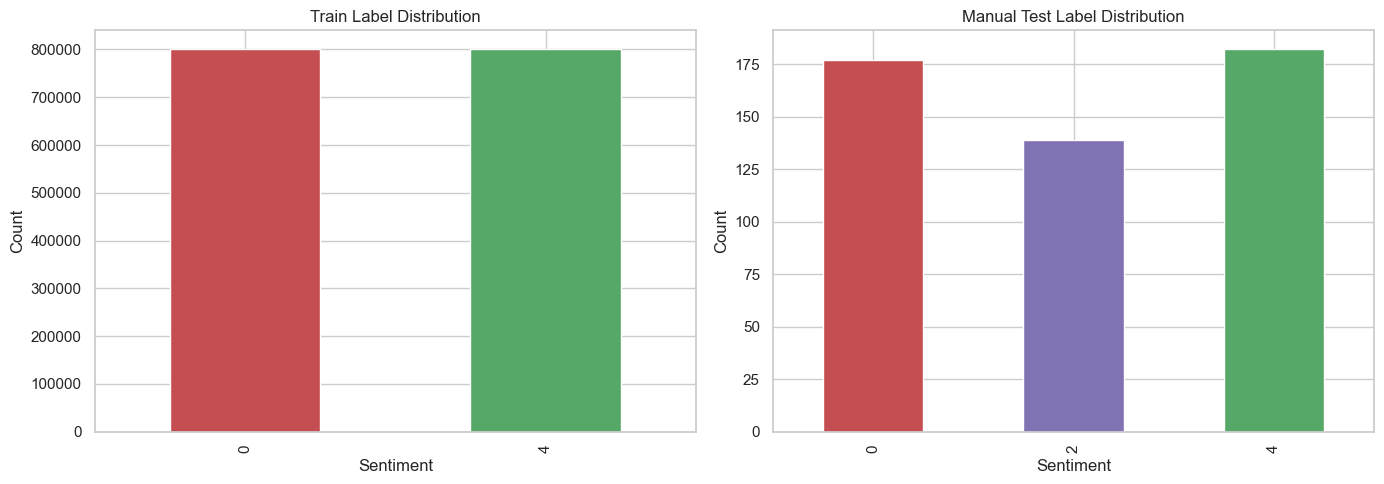

In [7]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df["sentiment"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["#c44e52", "#55a868"])
axes[0].set_title("Train Label Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

test_df["sentiment"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color=["#c44e52", "#8172b3", "#55a868"])
axes[1].set_title("Manual Test Label Distribution")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

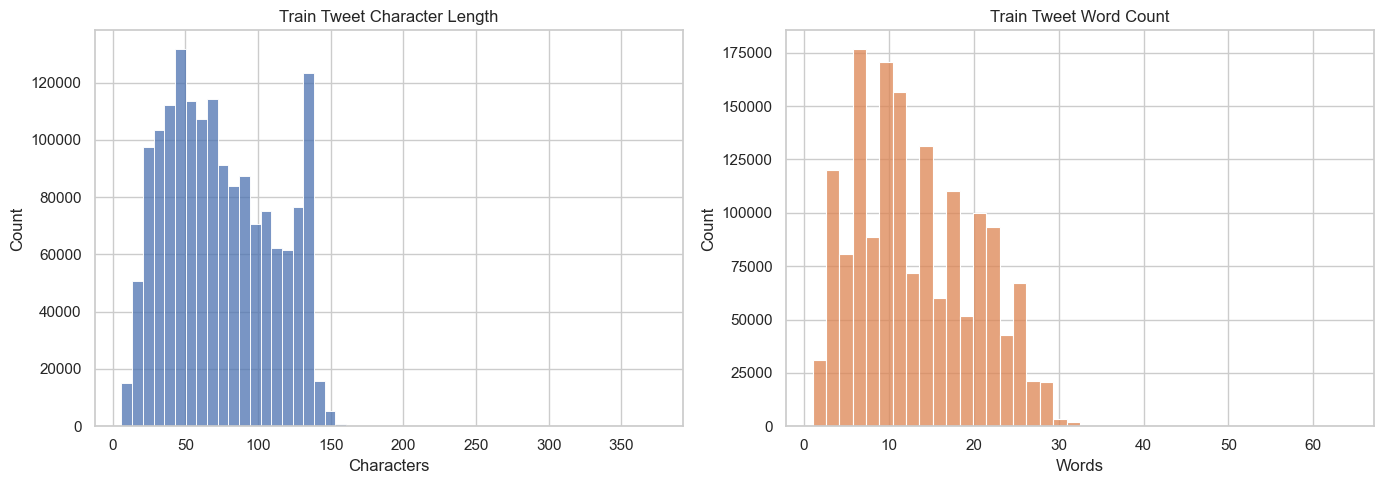

In [8]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_df["char_len"], bins=50, ax=axes[0], color="#4c72b0")
axes[0].set_title("Train Tweet Character Length")
axes[0].set_xlabel("Characters")

sns.histplot(train_df["word_count"], bins=40, ax=axes[1], color="#dd8452")
axes[1].set_title("Train Tweet Word Count")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

In [9]:
display(train_df.loc[train_df["sentiment"] == 0, ["sentiment", "text"]].head(5))
display(train_df.loc[train_df["sentiment"] == 4, ["sentiment", "text"]].head(5))

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."


,sentiment,text
800000,4,I LOVE @Health4UandPets u guys r the best!!
800001,4,im meeting up with one of my besties tonight! Cant wait!! - GIRL TALK!!
800002,4,"@DaRealSunisaKim Thanks for the Twitter add, Sunisa! I got to meet you once at a HIN show here in the DC area and you were a sweetheart."
800003,4,"Being sick can be really cheap when it hurts too much to eat real food Plus, your friends make you soup"
800004,4,@LovesBrooklyn2 he has that effect on everyone


## Initial Findings

- The training set is a balanced binary dataset with labels `0` and `4`.
- The manual test set includes neutral tweets with label `2`, so it cannot be used directly for binary evaluation without filtering.
- Tweets are short and noisy, with URLs, mentions, and hashtags appearing regularly.


## Modeling Scope

- The training file contains only labels `0` and `4`, so the implemented model is a binary classifier.
- Neutral rows with label `2` in the manual test file are excluded from scored evaluation.
- The notebook stops at EDA and problem framing so the reproducible training flow lives in Python modules instead of notebook cells.


## Where Training Lives

Reusable training and inference code has been moved out of the notebook:

- `sentiment_api/train.py`: training, evaluation, and batch prediction helpers
- `scripts/train_and_evaluate.py`: end-to-end training script that saves model weights, metadata, metrics, and sample predictions
- `app.py`: synchronous REST inference endpoint using the saved artifacts

Run training from the repository root with:

```bash
python scripts/train_and_evaluate.py
```


## Review Guidance

Use this notebook to review:

- dataset schema and loading assumptions
- label distribution and validation checks
- tweet length and noise characteristics
- the rationale for binary sentiment scope

Use the Python modules and script to review the reproducible implementation.
